In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error, smooth_ts
import os
import tqdm

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

In [ ]:
T = 100
dt = 0.5e-3
n = 256
noise = 0.005
n_conj = 20
bat_flight = generate_bat_flight(T=T, dt=dt)


net = BatHeadDirectionSystem(input_noise=0, intrinsic_noise=noise, n_conjunctive=n_conj)
net_anchor = BatHeadDirectionSystem(
    input_noise=0, intrinsic_noise=noise, n_conjunctive=n_conj
)

net.warm_up(initial_pos=bat_flight["dir_torus"][0])
net_anchor.warm_up(initial_pos=bat_flight["dir_torus"][0])

n_steps = bat_flight["pos"].shape[0]
recording_anchor = net_anchor.run_simulation(
    bat_flight["dir_vel"], dir=bat_flight["dir_torus"]
)
recording = net.run_simulation(bat_flight["dir_vel"])

100%|██████████| 199999/199999 [00:13<00:00, 15384.25it/s]


Ran warm up for 132 steps
Ran warm up for 132 steps


Running Simulation Steps: 100%|██████████| 200000/200000 [00:33<00:00, 5958.72it/s]


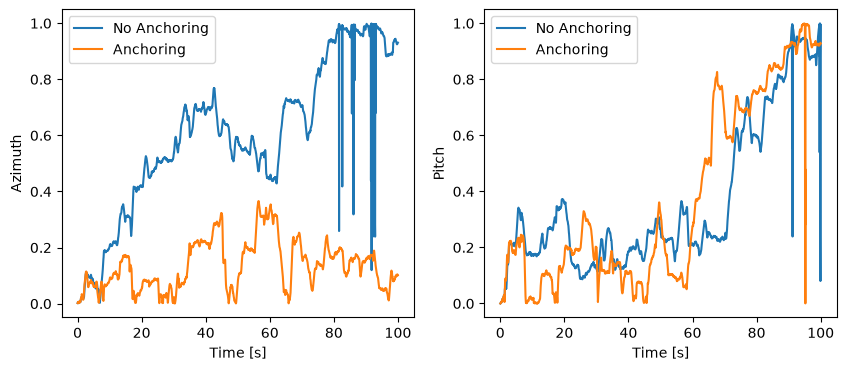

In [3]:
def smooth_ts(array: np.ndarray, interval: int):
    return (
        array[: (len(array) // interval) * interval]
        .reshape((-1,) + (interval,) + array.shape[1:])
        .mean(axis=1)
    )


interval = 100

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    anchored_error = angular_error(
        recording_anchor["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][:, angle_iter],
    )
    error = angular_error(
        recording["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][:, angle_iter],
    )

    ax[angle_iter].plot(
        smooth_ts(bat_flight["time"], interval),
        np.abs(smooth_ts(error, interval)),
        label="No Anchoring",
    )
    ax[angle_iter].plot(
        smooth_ts(bat_flight["time"], interval),
        np.abs(smooth_ts(anchored_error, interval)),
        label="Anchoring",
    )
    ax[angle_iter].legend()
    ax[angle_iter].set_ylabel(angle)
    ax[angle_iter].set_xlabel("Time [s]")

fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_anchoring_effect.png"))